In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/Assignment 8/part_A.zip" -d /content/


In [ ]:
!pip install scipy h5py opencv-python


### Import Necessary Libraies

In [ ]:
import os
import cv2
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob
from scipy.io import loadmat
from skimage.draw import disk

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, callbacks

## Define Datasets path

In [ ]:

train_img_dir = "/content/part_A/train_data/images"
train_gt_dir = "/content/part_A/train_data/ground-truth"
test_img_dir = "/content/part_A/test_data/images"
test_gt_dir = "/content/part_A/test_data/ground-truth"

density_map_dir = "/content/density_maps"
os.makedirs(density_map_dir, exist_ok=True)


### Density Map Generator

In [ ]:
def generate_density_map(image, points, sigma=4):
    h, w = image.shape[:2]
    density = np.zeros((h, w), dtype=np.float32)
    for point in points:
        x = min(int(point[0]), w - 1)
        y = min(int(point[1]), h - 1)
        rr, cc = disk((y, x), sigma, shape=density.shape)
        density[rr, cc] += 1
    return density

### Generate and save density maps

In [ ]:
train_imgs = sorted(glob(os.path.join(train_img_dir, "*.jpg")))

for img_path in tqdm(train_imgs):
    fname = os.path.basename(img_path).replace(".jpg", "")
    gt_path = os.path.join(train_gt_dir, f"GT_{fname}.mat")

    mat = loadmat(gt_path)
    points = mat["image_info"][0][0][0][0][0]

    image = cv2.imread(img_path)
    density = generate_density_map(image, points)

    np.save(os.path.join(density_map_dir, f"{fname}.npy"), density)

100%|██████████| 300/300 [00:15<00:00, 19.10it/s]


## U‑Net Model Definition

In [ ]:
def unet(input_shape=(224, 224, 3)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)

    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(c4)

    # Decoder
    u5 = layers.UpSampling2D()(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(256, 3, activation='relu', padding='same')(u5)

    u6 = layers.UpSampling2D()(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(128, 3, activation='relu', padding='same')(u6)

    u7 = layers.UpSampling2D()(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(64, 3, activation='relu', padding='same')(u7)

    outputs = layers.Conv2D(1, 1, activation='linear')(c7)

    return models.Model(inputs, outputs)


### Data Generator

In [ ]:
class CrowdDataset(tf.keras.utils.Sequence):
    def __init__(self, image_paths, density_paths, batch_size=4, input_size=(224, 224)):
        self.image_paths = image_paths
        self.density_paths = density_paths
        self.batch_size = batch_size
        self.input_size = input_size

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, idx):
        X = []
        Y = []
        for i in range(self.batch_size):
            index = idx * self.batch_size + i
            image = cv2.imread(self.image_paths[index])
            image = cv2.resize(image, self.input_size)
            image = image.astype(np.float32) / 255.0

            fname = os.path.basename(self.image_paths[index]).replace(".jpg", "")
            density = np.load(self.density_paths[index])
            density = cv2.resize(density, self.input_size)
            density = density.astype(np.float32)
            density *= (np.sum(density) / (np.sum(density) + 1e-6))  # Preserve total count

            X.append(image)
            Y.append(density[..., np.newaxis])
        return np.array(X), np.array(Y)


## Training Loop Preparing

In [ ]:
train_images = sorted(glob(os.path.join(train_img_dir, "*.jpg")))
train_density = sorted(glob(os.path.join(density_map_dir, "*.npy")))

train_gen = CrowdDataset(train_images, train_density, batch_size=4)

### Compile Model

In [ ]:
model = unet()
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 56, 56,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 56, 56,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 56, 56,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 768)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 56, 56,    │  1,769,728 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 112, 112,  │          0 │ conv2d_8[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 112, 112,  │          0 │ up_sampling2d_1[

 Total params: 7,008,321 (26.73 MB)

 Trainable params: 7,008,321 (26.73 MB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [ ]:

model.fit(train_gen, epochs=30)
model.save("crowd_unet_model.h5")

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 115ms/step - loss: 0.1171
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - loss: 0.0506
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0516
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - loss: 0.0514
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.0518
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - loss: 0.0534
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - loss: 0.0473
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - loss: 0.0485
Epoch 9/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - loss: 0.0453
Epoch 10/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - loss: 0.0513
Epoch 11/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - loss: 0.0458
Epoch 12/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - loss: 0.0439
Epoch 13/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - loss: 0.0427
Epoch 14/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - loss: 0.0505
Epoch 15/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - loss: 0

## Model Evaluation

In [ ]:
test_images = sorted(glob(os.path.join(test_img_dir, "*.jpg")))
test_gt = sorted(glob(os.path.join(test_gt_dir, "*.mat")))

mae = 0
mse = 0
for i in tqdm(range(len(test_images))):
    image = cv2.imread(test_images[i])
    image_resized = cv2.resize(image, (224, 224)).astype(np.float32) / 255.0

    gt = loadmat(test_gt[i])
    points = gt["image_info"][0][0][0][0][0]
    gt_count = len(points)

    pred_density = model.predict(np.expand_dims(image_resized, axis=0))[0, ..., 0]
    pred_count = np.sum(pred_density)

    mae += abs(gt_count - pred_count)
    mse += (gt_count - pred_count) ** 2

mae /= len(test_images)
mse = np.sqrt(mse / len(test_images))
print(f"MAE: {mae:.2f}, RMSE: {mse:.2f}")

  0%|          | 0/182 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


  1%|          | 1/182 [00:04<14:04,  4.66s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  1%|          | 2/182 [00:04<06:11,  2.07s/it]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


 99%|█████████▉| 181/182 [00:23<00:00, 10.65it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


100%|██████████| 182/182 [00:23<00:00,  7.69it/s]

MAE: 2700.10, RMSE: 3029.47


### Visuaization

In [ ]:
def visualize_result(image_path, mat_path, model, input_size=(224, 224)):
    # Load image
    image = cv2.imread(image_path)
    image_resized = cv2.resize(image, input_size).astype(np.float32) / 255.0

    # Ground truth count
    mat = loadmat(mat_path)
    points = mat["image_info"][0][0][0][0][0]
    gt_density = generate_density_map(image, points)
    gt_resized = cv2.resize(gt_density, input_size)

    # Predicted density
    pred_density = model.predict(np.expand_dims(image_resized, axis=0))[0, ..., 0]
    pred_count = np.sum(pred_density)
    gt_count = len(points)

    # Plot
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(gt_resized, cmap='jet')
    plt.title(f"Ground Truth (Count: {gt_count})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_density, cmap='jet')
    plt.title(f"U-Net Predicted (Count: {pred_count:.2f})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

### Visualization of some images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


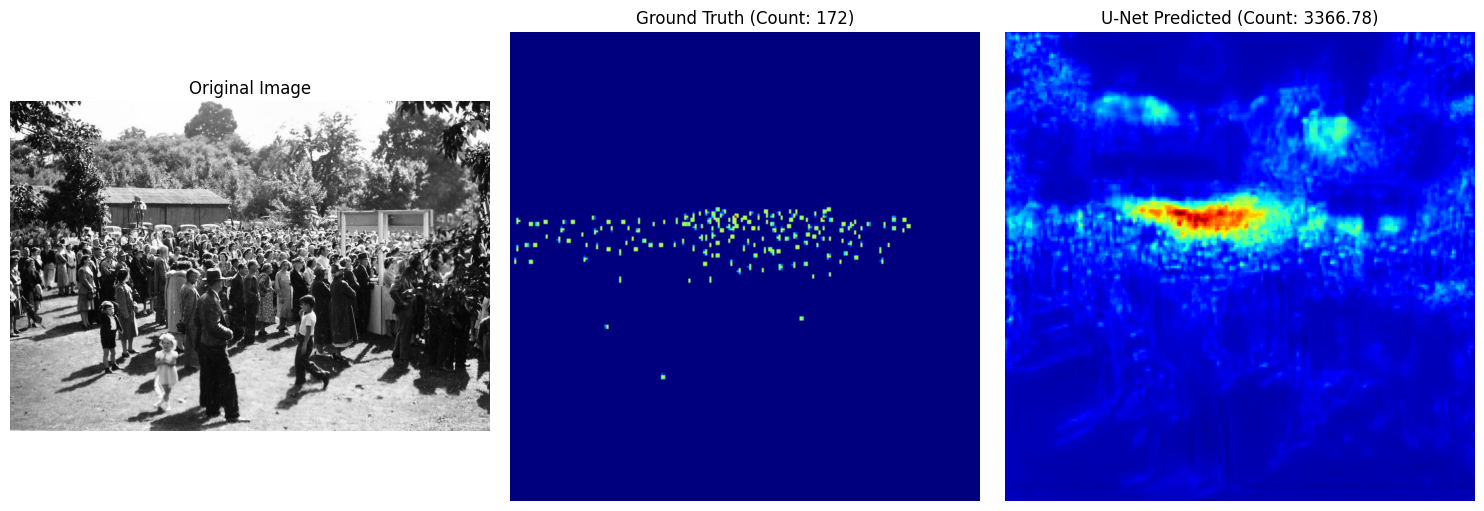

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


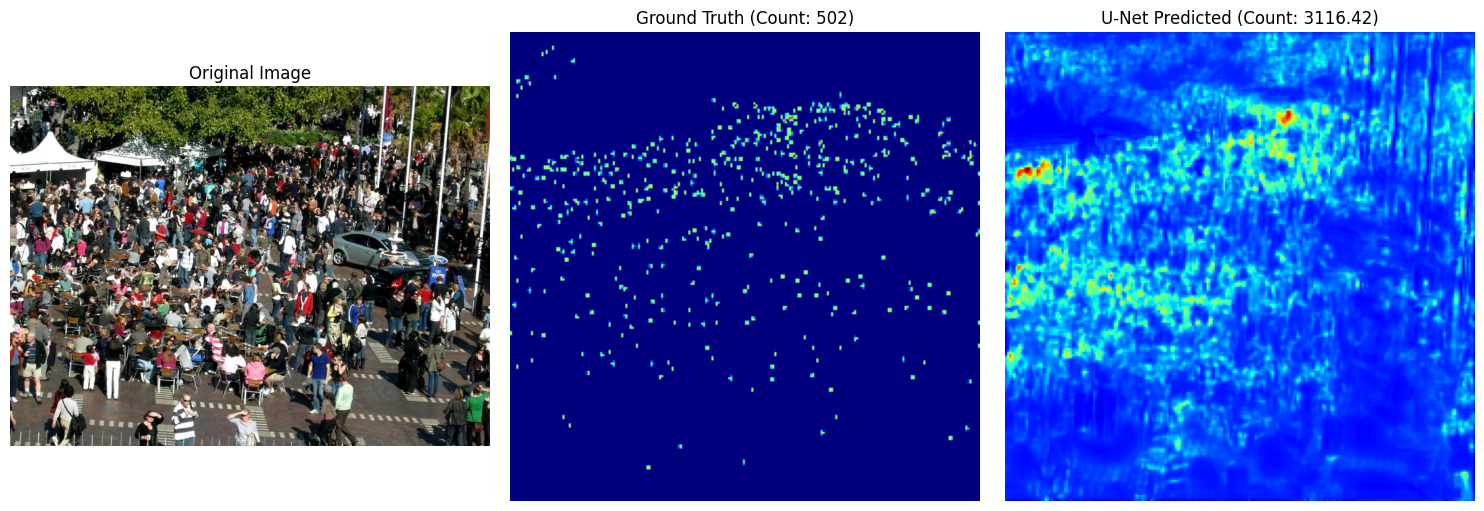

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


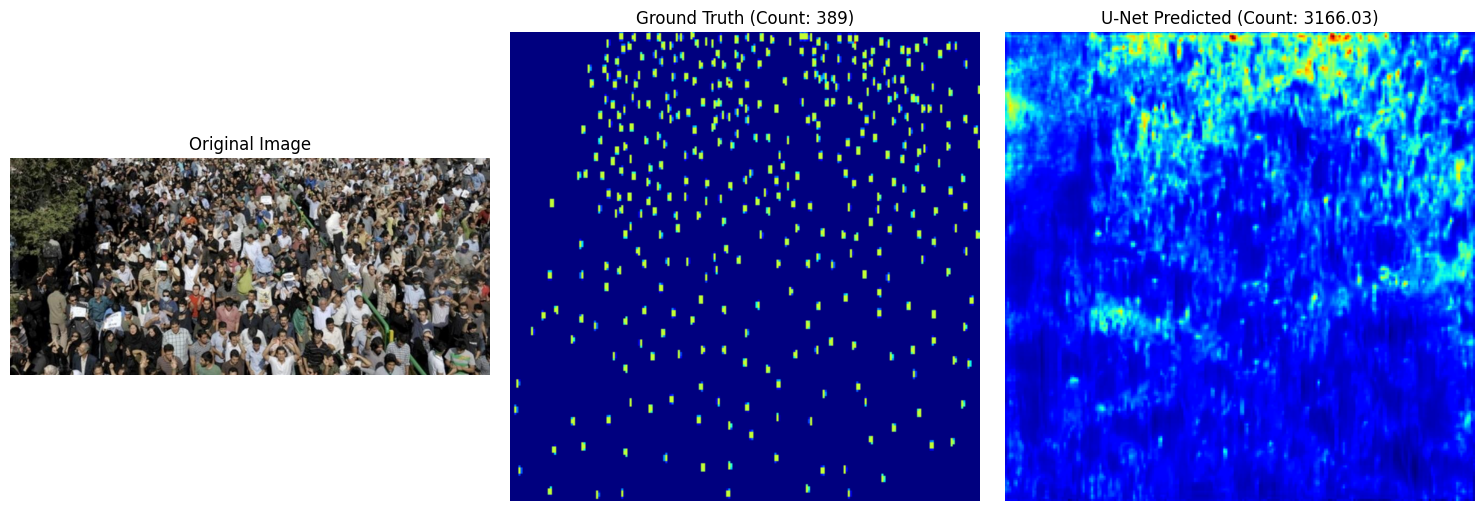

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


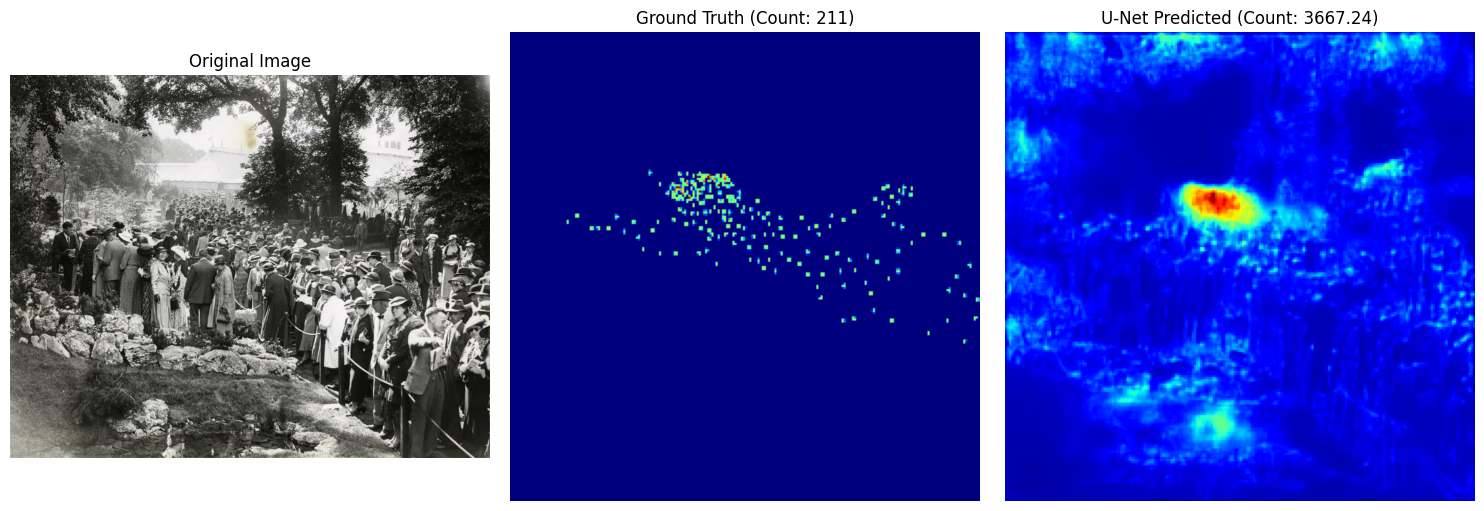

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


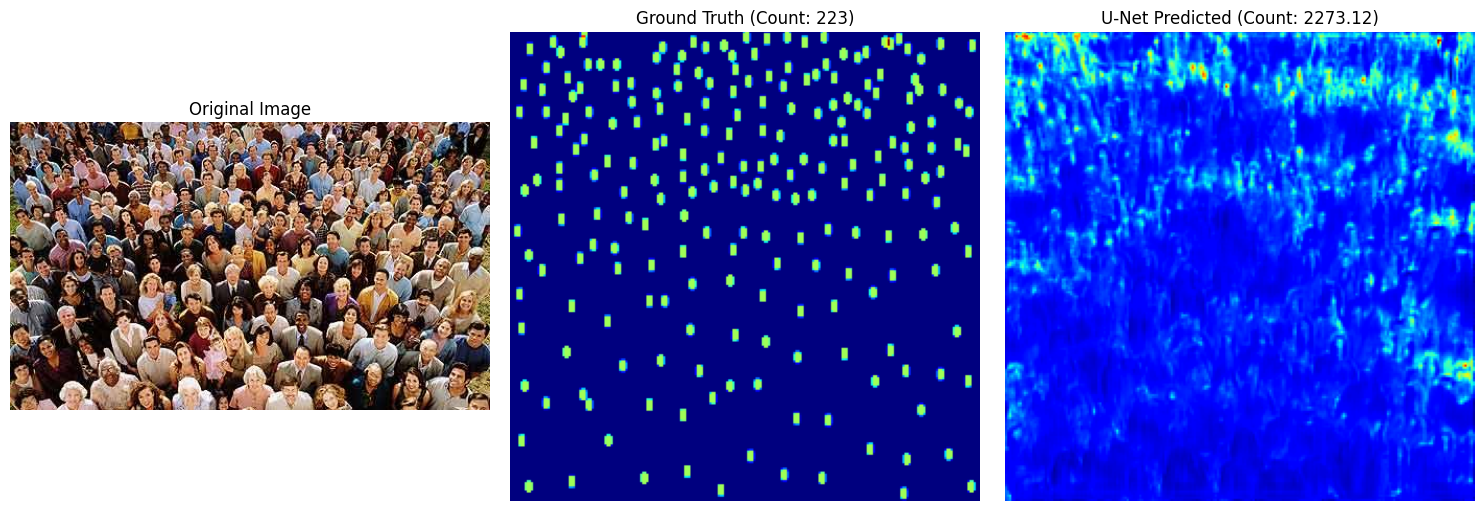

In [ ]:
for sample_index in range(5):
    visualize_result(test_images[sample_index], test_gt[sample_index], model)


In [ ]:
import os
print(os.listdir(train_gt_dir))

['GT_IMG_38.mat', 'GT_IMG_220.mat', 'GT_IMG_287.mat', 'GT_IMG_277.mat', 'GT_IMG_170.mat', 'GT_IMG_282.mat', 'GT_IMG_145.mat', 'GT_IMG_154.mat', 'GT_IMG_131.mat', 'GT_IMG_77.mat', 'GT_IMG_110.mat', 'GT_IMG_171.mat', 'GT_IMG_199.mat', 'GT_IMG_258.mat', 'GT_IMG_176.mat', 'GT_IMG_49.mat', 'GT_IMG_102.mat', 'GT_IMG_218.mat', 'GT_IMG_250.mat', 'GT_IMG_213.mat', 'GT_IMG_98.mat', 'GT_IMG_84.mat', 'GT_IMG_71.mat', 'GT_IMG_205.mat', 'GT_IMG_19.mat', 'GT_IMG_119.mat', 'GT_IMG_190.mat', 'GT_IMG_91.mat', 'GT_IMG_279.mat', 'GT_IMG_43.mat', 'GT_IMG_99.mat', 'GT_IMG_93.mat', 'GT_IMG_185.mat', 'GT_IMG_240.mat', 'GT_IMG_299.mat', 'GT_IMG_138.mat', 'GT_IMG_226.mat', 'GT_IMG_47.mat', 'GT_IMG_46.mat', 'GT_IMG_80.mat', 'GT_IMG_21.mat', 'GT_IMG_200.mat', 'GT_IMG_167.mat', 'GT_IMG_245.mat', 'GT_IMG_2.mat', 'GT_IMG_35.mat', 'GT_IMG_128.mat', 'GT_IMG_101.mat', 'GT_IMG_246.mat', 'GT_IMG_36.mat', 'GT_IMG_158.mat', 'GT_IMG_31.mat', 'GT_IMG_262.mat', 'GT_IMG_63.mat', 'GT_IMG_278.mat', 'GT_IMG_67.mat', 'GT_IMG_26.ma